**Q1**. Trong số các khách hàng có nhiều hơn một đơn hàng, **trung vị số ngày giữa hai lần
mua liên tiếp** (inter-order gap) xấp xỉ là bao nhiêu? (Tính từ orders.csv)

        order_id order_date  customer_id    zip order_status payment_method  \
370532    477922 2017-04-03       157563  59937    delivered      apple_pay   
397649    512958 2017-07-01       157563  59937    delivered    credit_card   
437458    564067 2018-03-02       157563  59937    delivered      apple_pay   
484249    624402 2018-08-20       157563  59937      created    credit_card   
531056    684810 2019-08-30       157563  59937    delivered    credit_card   
549990    709267 2020-04-11       157563  59937    delivered    credit_card   
557438    718824 2020-05-29       157563  59937    delivered    credit_card   
559725    721751 2020-06-22       157563  59937    delivered         paypal   
591841    763157 2021-05-27       157563  59937    delivered    credit_card   
637881    822601 2022-08-31       157563  59937    cancelled            cod   

       device_type    order_source prev_order_date  inter_order_gap  
370532      tablet  organic_search      2017-02-22          

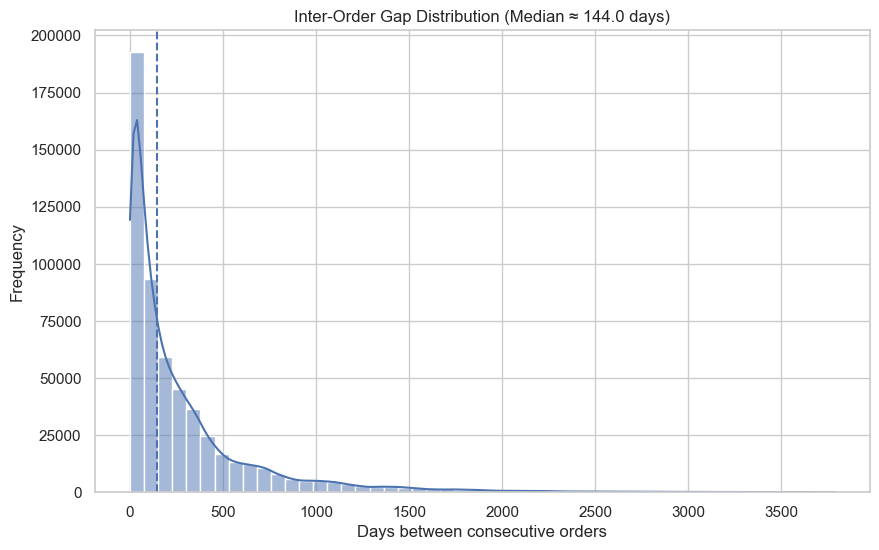

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/orders.csv", parse_dates=['order_date'])

# Sort theo customer + thời gian
df = df.sort_values(by=['customer_id', 'order_date'])



# Tính khoảng cách giữa các đơn (ngày)
df['prev_order_date'] = df.groupby('customer_id')['order_date'].shift(1)
df['inter_order_gap'] = (df['order_date'] - df['prev_order_date']).dt.days

print(df.tail(10))

# Lọc khách có >1 đơn (tức là có gap)
gap_df = df[df['inter_order_gap'].notna()]

median_gap = gap_df['inter_order_gap'].median()
print(f"Median inter-order gap: {median_gap:.2f} days")

# Visualization
plt.figure(figsize=(10, 6))

sns.histplot(gap_df['inter_order_gap'], bins=50, kde=True)

# Vẽ đường median
plt.axvline(median_gap, linestyle='--')

plt.title(f"Inter-Order Gap Distribution (Median ≈ {median_gap:.1f} days)")
plt.xlabel("Days between consecutive orders")
plt.ylabel("Frequency")

plt.show()

**Q2.** Phân khúc sản phẩm (segment) nào trong products.csv có **tỷ suất lợi nhuận gộp
trung bình** cao nhất, với công thức (price − cogs)/price?

Average Gross Margin by Segment:
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: gross_margin, dtype: float64

Segment có margin cao nhất: Standard (31.34%)


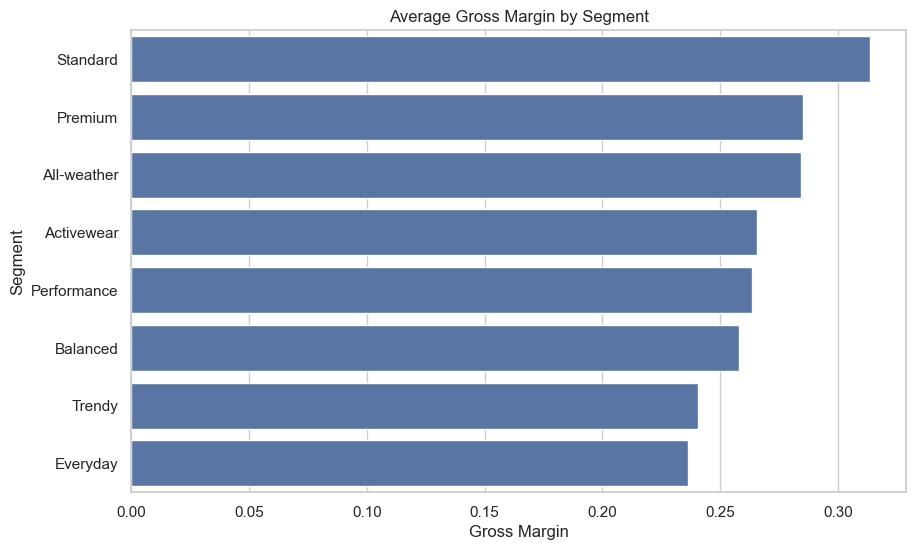

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/products.csv")

df['gross_margin'] = (df['price'] - df['cogs']) / df['price']
segment_margin = df.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)

print("Average Gross Margin by Segment:")
print(segment_margin)

top_segment = segment_margin.idxmax()
top_value = segment_margin.max()

print(f"\nSegment có margin cao nhất: {top_segment} ({top_value:.2%})")

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(x=segment_margin.values, y=segment_margin.index)

plt.title("Average Gross Margin by Segment")
plt.xlabel("Gross Margin")
plt.ylabel("Segment")

plt.show()

**Q3.** Trong các bản ghi trả hàng liên kết với sản phẩm thuộc danh mục **Streetwear** (join
returns với products theo product_id), **lý do trả hàng** nào xuất hiện nhiều nhất?

Return reason counts (Streetwear):
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64

 Lý do trả hàng phổ biến nhất: wrong_size (7626 lần)


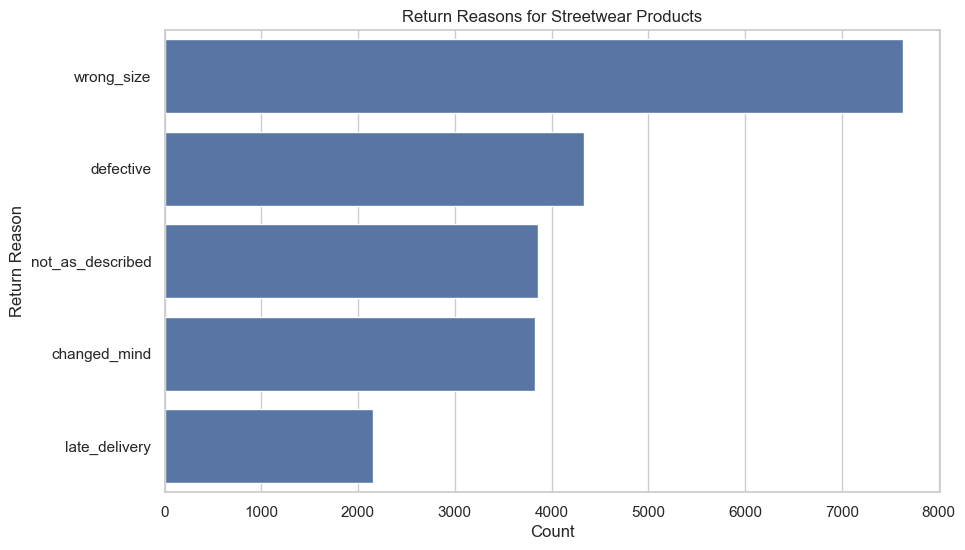

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
returns = pd.read_csv("data/returns.csv")
products = pd.read_csv("data/products.csv")

# join data
df = returns.merge(products[['product_id', 'category']], on='product_id', how='left')

streetwear_returns = df[df['category'] == 'Streetwear']

reason_counts = streetwear_returns['return_reason'].value_counts()

print("Return reason counts (Streetwear):")
print(reason_counts)

top_reason = reason_counts.idxmax()
top_count = reason_counts.max()

print(f"\n Lý do trả hàng phổ biến nhất: {top_reason} ({top_count} lần)")

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    x=reason_counts.values,
    y=reason_counts.index
)

plt.title("Return Reasons for Streetwear Products")
plt.xlabel("Count")
plt.ylabel("Return Reason")

plt.show()

**Q4.** Trong web_traffic.csv, nguồn truy cập (traffic_source) nào có **tỷ lệ thoát trung
bình** (bounce_rate) **thấp nhất** trên tất cả các ngày xuất hiện nguồn đó trong cột traffic_source?

🔹 Average Bounce Rate by Traffic Source:
traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64

Traffic source có bounce rate thấp nhất: email_campaign (0.4458%)


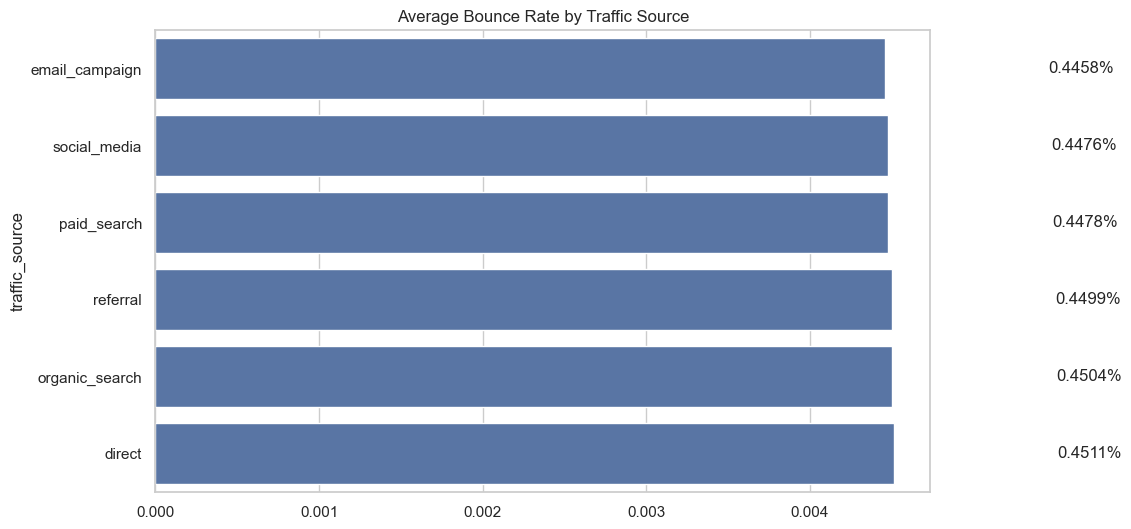

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/web_traffic.csv")

bounce_by_source = df.groupby('traffic_source')['bounce_rate'].mean().sort_values()

print("🔹 Average Bounce Rate by Traffic Source:")
print(bounce_by_source)

best_source = bounce_by_source.idxmin()
best_value = bounce_by_source.min()

print(f"\nTraffic source có bounce rate thấp nhất: {best_source} ({best_value:.4%})")

# Visualization
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=bounce_by_source.values,
    y=bounce_by_source.index
)

for i, v in enumerate(bounce_by_source.values):
    ax.text(v + 0.001, i, f"{v:.4%}", va='center')

plt.title("Average Bounce Rate by Traffic Source")
plt.show()

**Q5.** Tỷ lệ phần trăm các dòng trong order_items.csv có áp dụng khuyến mãi (tức là promo_id
không null) xấp xỉ là bao nhiêu?

Total rows: 714669
Rows with promo: 276316
Percentage of promo usage: 38.66%


C:\Users\nguye\AppData\Local\Temp\ipykernel_8124\328995364.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/order_items.csv")


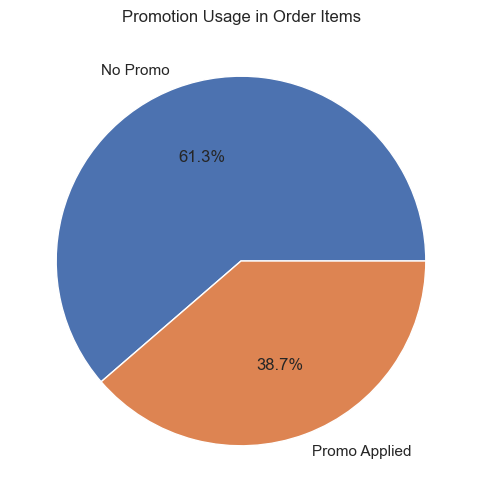

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/order_items.csv")

total_rows = len(df)
promo_rows = df['promo_id'].notna().sum()

promo_pct = promo_rows / total_rows * 100

print(f"Total rows: {total_rows}")
print(f"Rows with promo: {promo_rows}")
print(f"Percentage of promo usage: {promo_pct:.2f}%")

# Visualization
labels = ['No Promo', 'Promo Applied']
values = [total_rows - promo_rows, promo_rows]

plt.figure(figsize=(6, 6))

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Promotion Usage in Order Items")

plt.show()

**Q6.** Trong customers.csv, xét các khách hàng có age_group khác null, nhóm tuổi nào có **số
đơn hàng trung bình trên mỗi khách hàng** cao nhất? (tổng số đơn / số khách hàng trong
nhóm)

Average Orders per Customer by Age Group:
age_group
55+      7.268731
45-54    7.220264
35-44    7.206159
25-34    7.112230
18-24    7.068577
Name: order_count, dtype: float64

Nhóm tuổi có số đơn trung bình cao nhất: 55+ (7.27 đơn/khách)


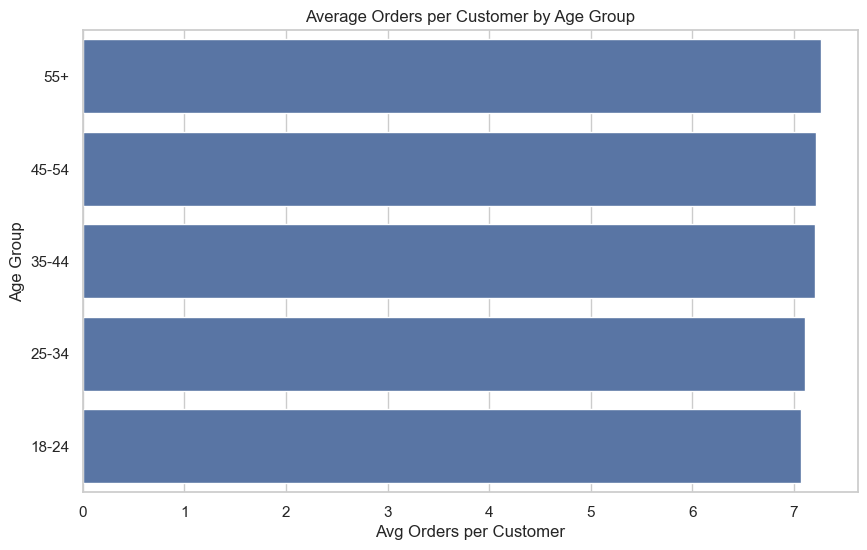

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")

df = orders.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')


df = df[df['age_group'].notna()]


# Số đơn mỗi khách
orders_per_customer = df.groupby(['age_group', 'customer_id']).size().reset_index(name='order_count')

# Trung bình theo nhóm tuổi
avg_orders = orders_per_customer.groupby('age_group')['order_count'].mean().sort_values(ascending=False)

print("Average Orders per Customer by Age Group:")
print(avg_orders)

top_group = avg_orders.idxmax()
top_value = avg_orders.max()

print(f"\nNhóm tuổi có số đơn trung bình cao nhất: {top_group} ({top_value:.2f} đơn/khách)")

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_orders.values,
    y=avg_orders.index
)

plt.title("Average Orders per Customer by Age Group")
plt.xlabel("Avg Orders per Customer")
plt.ylabel("Age Group")

plt.show()

**Q7.** Vùng (region) nào trong geography.csv tạo ra **tổng doanh thu cao nhất** trong
sales_train.csv?

C:\Users\nguye\AppData\Local\Temp\ipykernel_8124\2854595093.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("data/order_items.csv")


🔹 Total Revenue by Region:
region
East       7.637533e+09
Central    4.941908e+09
West       3.851035e+09
Name: revenue, dtype: float64

Region có doanh thu cao nhất: East (7,637,532,676)


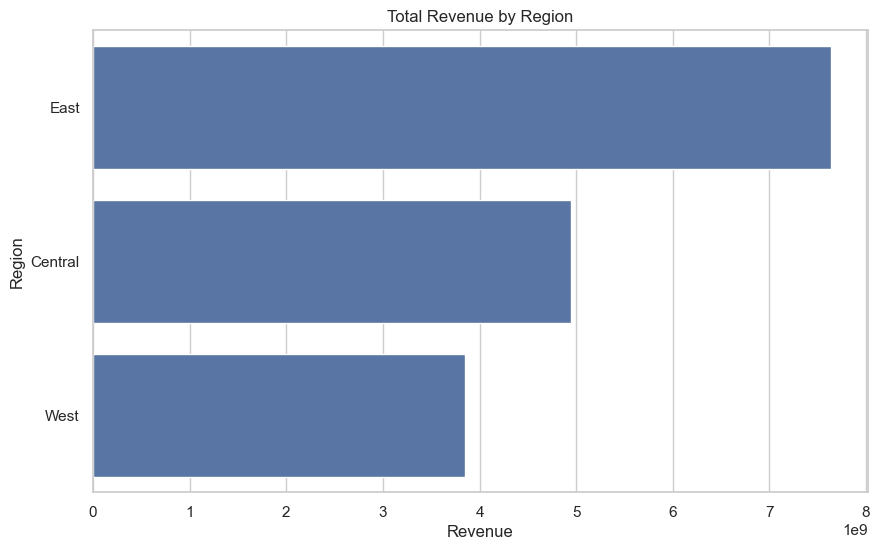

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("data/orders.csv")
order_items = pd.read_csv("data/order_items.csv")
geo = pd.read_csv("data/geography.csv")

order_items['revenue'] = order_items['quantity'] * order_items['unit_price']

df = order_items.merge(orders[['order_id', 'zip']], on='order_id', how='left')
df = df.merge(geo[['zip', 'region']], on='zip', how='left')

revenue_by_region = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

print("🔹 Total Revenue by Region:")
print(revenue_by_region)

top_region = revenue_by_region.idxmax()
top_value = revenue_by_region.max()

print(f"\nRegion có doanh thu cao nhất: {top_region} ({top_value:,.0f})")

plt.figure(figsize=(10, 6))

sns.barplot(
    x=revenue_by_region.values,
    y=revenue_by_region.index
)

plt.title("Total Revenue by Region")
plt.xlabel("Revenue")
plt.ylabel("Region")

plt.show()

**Q8.** Trong các đơn hàng có order_status = ’cancelled’ trong orders.csv, **phương thức
thanh toán** nào được sử dụng nhiều nhất?

🔹 Payment method usage (cancelled orders):
payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64

🏆 Phương thức thanh toán phổ biến nhất: credit_card (28452 đơn)


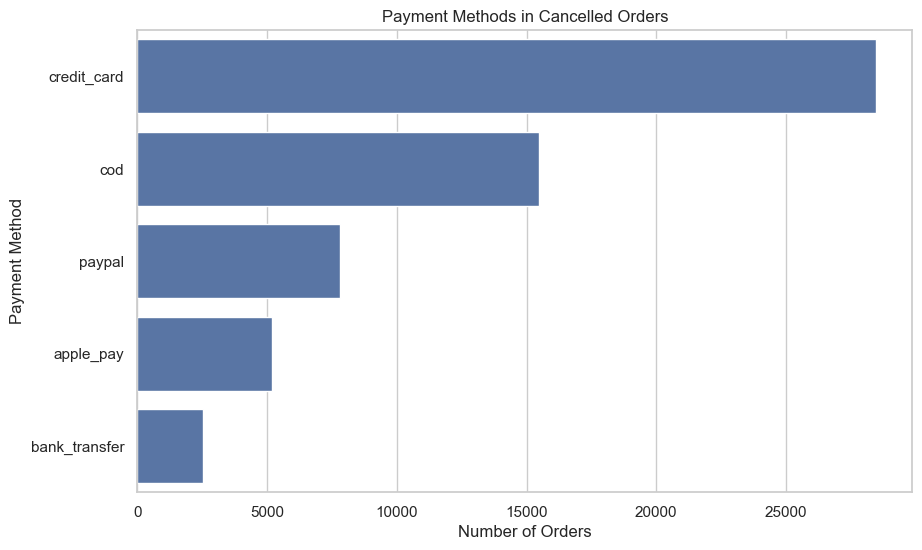

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/orders.csv")


cancelled_df = df[df['order_status'] == 'cancelled']

payment_counts = cancelled_df['payment_method'].value_counts()

print("🔹 Payment method usage (cancelled orders):")
print(payment_counts)

top_method = payment_counts.idxmax()
top_count = payment_counts.max()

print(f"\n🏆 Phương thức thanh toán phổ biến nhất: {top_method} ({top_count} đơn)")

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_counts.values,
    y=payment_counts.index
)

plt.title("Payment Methods in Cancelled Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Payment Method")

plt.show()

**Q9.** Trong bốn kích thước sản phẩm (S, M, L, XL), kích thước nào có **tỷ lệ trả hàng cao
nhất,** được định nghĩa là số bản ghi trong returns chia cho số dòng trong order_items (join
với products theo product_id)?

C:\Users\nguye\AppData\Local\Temp\ipykernel_8124\2556022913.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("data/order_items.csv")


🔹 Return rate by size:
size
S     0.056515
L     0.056250
M     0.055682
XL    0.055200
dtype: float64

🏆 Size có tỷ lệ trả hàng cao nhất: S (5.65%)


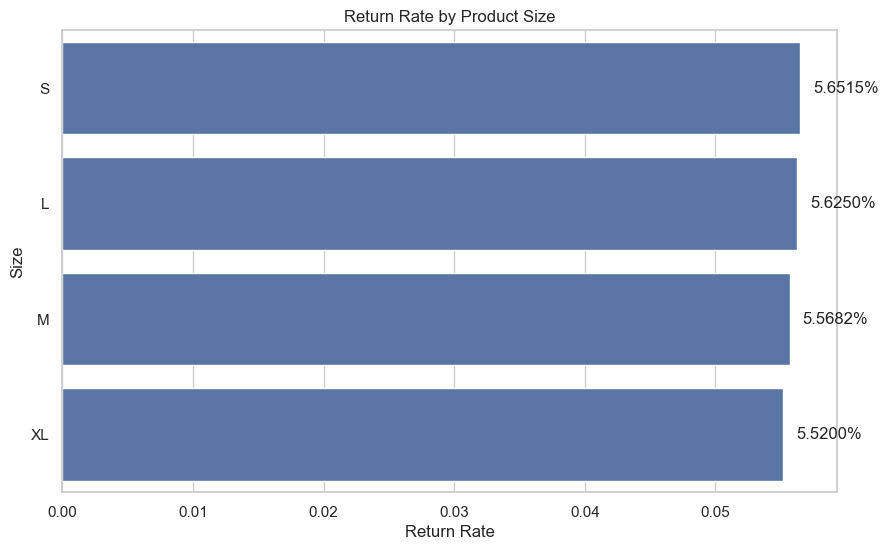

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
order_items = pd.read_csv("data/order_items.csv")
products = pd.read_csv("data/products.csv")
returns = pd.read_csv("data/returns.csv")


# order_items + products → lấy size
oi = order_items.merge(products[['product_id', 'size']], on='product_id', how='left')

# đánh dấu item bị return
returns_flag = returns[['order_id', 'product_id']].copy()
returns_flag['is_returned'] = 1

# merge để biết item nào bị return
df = oi.merge(returns_flag, on=['order_id', 'product_id'], how='left')
df['is_returned'] = df['is_returned'].fillna(0)

# tổng order_items theo size
total_items = df.groupby('size').size()

# số item bị return theo size
returned_items = df.groupby('size')['is_returned'].sum()

# return rate
return_rate = (returned_items / total_items).sort_values(ascending=False)

print("🔹 Return rate by size:")
print(return_rate)

top_size = return_rate.idxmax()
top_value = return_rate.max()

print(f"\n🏆 Size có tỷ lệ trả hàng cao nhất: {top_size} ({top_value:.2%})")


# Visualization
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=return_rate.values,
    y=return_rate.index,
    order=return_rate.index
)

# Add label %
for i, v in enumerate(return_rate.values):
    ax.text(v + 0.001, i, f"{v:.4%}", va='center')

plt.title("Return Rate by Product Size")
plt.xlabel("Return Rate")
plt.ylabel("Size")

plt.show()

**Q10.** Trong payments.csv, **kế hoạch trả góp** nào có **giá trị thanh toán trung bình trên
mỗi đơn hàng** cao nhất?

🔹 Average Payment Value by Installments:
installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64

 Kế hoạch trả góp có giá trị cao nhất: 6 kỳ (24,447)


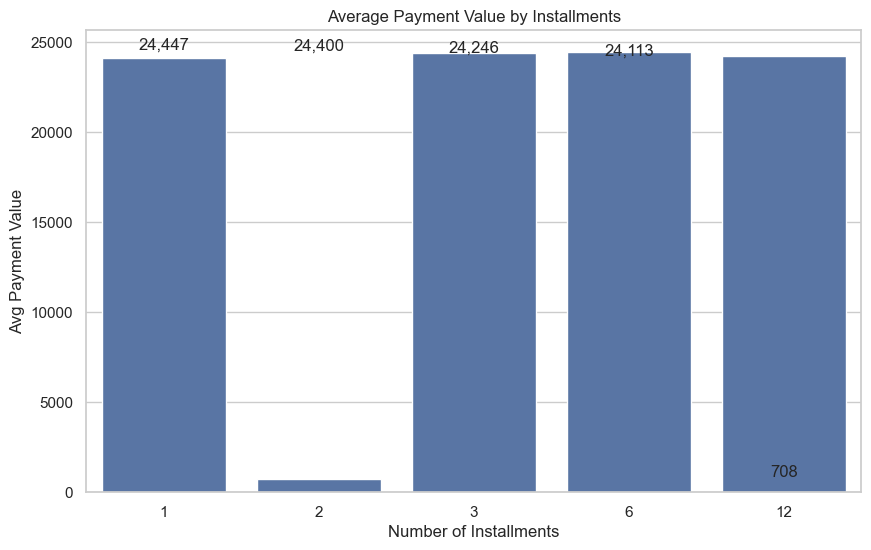

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
df = pd.read_csv("data/payments.csv")

avg_payment = df.groupby('installments')['payment_value'].mean().sort_values(ascending=False)

print("🔹 Average Payment Value by Installments:")
print(avg_payment)

top_plan = avg_payment.idxmax()
top_value = avg_payment.max()

print(f"\n Kế hoạch trả góp có giá trị cao nhất: {top_plan} kỳ ({top_value:,.0f})")

# Visualization
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=avg_payment.index,
    y=avg_payment.values
)

# Hiển thị giá trị trên cột
for i, v in enumerate(avg_payment.values):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.title("Average Payment Value by Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Avg Payment Value")

plt.show()